# Análisis Exploratorio de Datos (EDA)

## Objetivo

El objetivo de este análisis es explorar el dataset analítico integrado a nivel provincia-año, con el fin de identificar patrones, relaciones y tendencias relevantes que permitan comprender la incidencia de la violencia de género en España.

Este análisis servirá como base para la construcción de modelos predictivos en fases posteriores.

In [0]:
from pyspark.sql import functions as F

df_analitico = spark.read.format("delta").load(
    "/Volumes/workspace/default/tfm_visnu_raw/preprocess/dataset_analitico_final_delta"
)

display(df_analitico)

anio,provincia,denuncias,victimas,ordenes_proteccion,quebrantamientos,poblacion_hombres,poblacion_mujeres,poblacion_total,renta_media_hogar,renta_media_persona,tasa_actividad_total,tasa_actividad_hombres,tasa_actividad_mujeres,tasa_empleo_total,tasa_empleo_hombres,tasa_empleo_mujeres,tasa_paro_total,tasa_paro_hombres,tasa_paro_mujeres,tasa_denuncias_100k,tasa_victimas_100k,tasa_ordenes_100k,tasa_quebrantamientos_100k,ratio_ordenes_denuncias,ratio_quebrantamientos_denuncias,porcentaje_mujeres
2021,A CORUNA,1943.0,1916.0,700.0,241.0,537361.0,583140.0,1120501.0,32643.0,13319.0,52.70249999999999,57.724999999999994,48.167500000000004,47.122499999999995,51.915,42.795,10.6,10.094999999999999,11.145,173.4045752748101,170.99493887109426,62.472054911151346,21.50823604798211,0.3602676273803397,0.1240349974266598,0.5204279157269829
2021,A CORUNA,54.0,54.0,24.0,11.0,537361.0,583140.0,1120501.0,32643.0,13319.0,52.70249999999999,57.724999999999994,48.167500000000004,47.122499999999995,51.915,42.795,10.6,10.094999999999999,11.145,4.819272807431675,4.819272807431675,2.1418990255251895,0.9817037200323784,0.4444444444444444,0.2037037037037037,0.5204279157269829
2021,ALAVA,53.0,53.0,5.0,1.0,164299.0,169186.0,333485.0,36546.0,15539.0,57.25749999999999,61.7725,52.942499999999995,50.755,54.29,47.37499999999999,11.365,12.129999999999999,10.522499999999999,15.89276879020046,15.89276879020046,1.4993178103962697,0.29986356207925396,0.09433962264150944,0.018867924528301886,0.5073271661394065
2021,ALBACETE,969.0,956.0,336.0,108.0,193487.0,193239.0,386726.0,29451.0,11652.0,57.052499999999995,63.6175,50.55499999999999,48.165,56.010000000000005,40.4075,15.5275,11.9675,19.91,250.56499950869608,247.20344636771256,86.88321964388223,27.92674917124786,0.34674922600619196,0.11145510835913312,0.49967935954655235
2021,ALICANTE,10659.0,10627.0,2984.0,1433.0,935234.0,951802.0,1887036.0,27380.0,10770.0,56.585,62.307500000000005,51.015,46.00000000000001,52.14,40.0275,18.705,16.325,21.5225,564.854088634239,563.1583075256647,158.1315883745726,75.93919776835206,0.27995121493573505,0.13444037902242237,0.5043899533448223
2021,ALMERIA,2433.0,2218.0,580.0,348.0,372823.0,357607.0,730430.0,27184.0,10103.0,61.765,69.485,53.765,49.89,57.025,42.4875,19.255000000000003,17.97,20.9875,333.09146667031746,303.656750133483,79.40528182029763,47.64316909217858,0.23838882038635428,0.14303329223181258,0.4895842175157099
2021,ASTURIAS,1578.0,1571.0,421.0,246.0,483186.0,528931.0,1012117.0,31623.0,14057.0,50.412499999999994,55.3125,46.027499999999996,44.19,49.055,39.8375,12.335,11.317499999999999,13.4275,155.91082849117245,155.21920884640807,41.5959814922583,24.305490373148558,0.26679340937896073,0.155893536121673,0.5225986718926764
2021,AVILA,374.0,374.0,141.0,42.0,79884.0,79014.0,158898.0,27023.0,12123.0,52.325,57.545,47.06,44.2,51.68749999999999,36.655,15.49,10.1675,22.03,235.37111857921434,235.37111857921434,88.73617037344711,26.432050749537442,0.3770053475935829,0.11229946524064172,0.4972623947437979
2021,BADAJOZ,1970.0,1970.0,650.0,130.0,331856.0,339236.0,671092.0,26050.0,10549.0,55.74499999999999,62.4475,49.287499999999994,44.32,52.62499999999999,36.3175,20.5275,15.7625,26.332499999999996,293.55140576850863,293.55140576850863,96.85706281702062,19.37141256340412,0.3299492385786802,0.06598984771573604,0.5054985009506894
2021,BARCELONA,11536.0,11262.0,2780.0,1335.0,2785890.0,2916372.0,5702262.0,39511.0,15297.0,61.370000000000005,65.91,57.1325,54.4225,59.2025,49.957499999999996,11.327499999999999,10.1775,12.5625,202.30568149972763,197.50057082610377,48.75258274698707,23.411761858715014,0.24098474341192788,0.1157246879334258,0.5114412491043028


## Validación del dataset

El dataset presenta cobertura completa a nivel provincial para el periodo disponible tras la integración de fuentes.

In [0]:
display(
    df_analitico.selectExpr(
        "count(*) as num_filas",
        "count(distinct provincia) as num_provincias",
        "min(anio) as anio_min",
        "max(anio) as anio_max"
    )
)

num_filas,num_provincias,anio_min,anio_max
159,52,2021,2023


Los resultados confirman:

- 159 observaciones totales  
- 52 provincias  
- Periodo temporal: 2021–2023  

Esto garantiza que el dataset es consistente y adecuado para el análisis exploratorio.

### Validación de calidad del dato

Se analiza la presencia de valores nulos en las variables clave del dataset.

In [0]:
display(
    df_analitico.selectExpr(
        "sum(case when provincia is null then 1 else 0 end) as null_provincia",
        "sum(case when anio is null then 1 else 0 end) as null_anio",
        "sum(case when denuncias is null then 1 else 0 end) as null_denuncias",
        "sum(case when victimas is null then 1 else 0 end) as null_victimas",
        "sum(case when renta_media_persona is null then 1 else 0 end) as null_renta_media_persona",
        "sum(case when tasa_paro_mujeres is null then 1 else 0 end) as null_tasa_paro_mujeres",
        "sum(case when poblacion_total is null then 1 else 0 end) as null_poblacion_total",
        "sum(case when tasa_denuncias_100k is null then 1 else 0 end) as null_tasa_denuncias_100k"
    )
)

null_provincia,null_anio,null_denuncias,null_victimas,null_renta_media_persona,null_tasa_paro_mujeres,null_poblacion_total,null_tasa_denuncias_100k
0,0,0,0,0,0,0,0


Se observa ausencia de valores nulos en las variables principales, lo que confirma la correcta integración de las fuentes de datos.

In [0]:
display(
    df_analitico
    .groupBy("anio")
    .agg(F.avg("tasa_denuncias_100k").alias("media_tasa_denuncias_100k"))
    .orderBy("anio")
)

anio,media_tasa_denuncias_100k
2021,215.62096065353592
2022,233.95913240179863
2023,261.5289552741574


Se observa una tendencia creciente en la tasa de denuncias a lo largo del periodo 2021 al 2023...

In [0]:
display(
    df_analitico
    .groupBy("provincia")
    .agg(F.avg("tasa_denuncias_100k").alias("media_tasa_denuncias_100k"))
    .orderBy(F.desc("media_tasa_denuncias_100k"))
)

provincia,media_tasa_denuncias_100k
ALICANTE,659.6508211449715
MALAGA,638.7535657286013
GRANADA,554.9568969817186
HUELVA,462.96399833109496
CADIZ,441.11322925307803
MELILLA,434.50878158850566
MURCIA,434.48943441145894
GUADALAJARA,402.2694821484092
MADRID,385.0019487156407
ALMERIA,365.92827482159095


In [0]:
display(
    df_analitico.select(
        "tasa_denuncias_100k",
        "tasa_victimas_100k",
        "renta_media_persona",
        "renta_media_hogar",
        "tasa_paro_mujeres",
        "tasa_actividad_mujeres",
        "tasa_empleo_mujeres",
        "porcentaje_mujeres",
        "ratio_ordenes_denuncias"
    )
)
print("Corr tasa_denuncias_100k vs renta_media_persona:",
      df_analitico.stat.corr("tasa_denuncias_100k", "renta_media_persona"))

print("Corr tasa_denuncias_100k vs tasa_paro_mujeres:",
      df_analitico.stat.corr("tasa_denuncias_100k", "tasa_paro_mujeres"))

print("Corr tasa_denuncias_100k vs tasa_actividad_mujeres:",
      df_analitico.stat.corr("tasa_denuncias_100k", "tasa_actividad_mujeres"))

print("Corr tasa_denuncias_100k vs tasa_empleo_mujeres:",
      df_analitico.stat.corr("tasa_denuncias_100k", "tasa_empleo_mujeres"))

tasa_denuncias_100k,tasa_victimas_100k,renta_media_persona,renta_media_hogar,tasa_paro_mujeres,tasa_actividad_mujeres,tasa_empleo_mujeres,porcentaje_mujeres,ratio_ordenes_denuncias
173.4045752748101,170.99493887109426,13319.0,32643.0,11.145,48.167500000000004,42.795,0.5204279157269829,0.3602676273803397
4.819272807431675,4.819272807431675,13319.0,32643.0,11.145,48.167500000000004,42.795,0.5204279157269829,0.4444444444444444
15.89276879020046,15.89276879020046,15539.0,36546.0,10.522499999999999,52.942499999999995,47.37499999999999,0.5073271661394065,0.09433962264150944
250.56499950869608,247.20344636771256,11652.0,29451.0,19.91,50.55499999999999,40.4075,0.49967935954655235,0.34674922600619196
564.854088634239,563.1583075256647,10770.0,27380.0,21.5225,51.015,40.0275,0.5043899533448223,0.27995121493573505
333.09146667031746,303.656750133483,10103.0,27184.0,20.9875,53.765,42.4875,0.4895842175157099,0.23838882038635428
155.91082849117245,155.21920884640807,14057.0,31623.0,13.4275,46.027499999999996,39.8375,0.5225986718926764,0.26679340937896073
235.37111857921434,235.37111857921434,12123.0,27023.0,22.03,47.06,36.655,0.4972623947437979,0.3770053475935829
293.55140576850863,293.55140576850863,10549.0,26050.0,26.332499999999996,49.287499999999994,36.3175,0.5054985009506894,0.3299492385786802
202.30568149972763,197.50057082610377,15297.0,39511.0,12.5625,57.1325,49.957499999999996,0.5114412491043028,0.24098474341192788


Corr tasa_denuncias_100k vs renta_media_persona: -0.3206805233504653
Corr tasa_denuncias_100k vs tasa_paro_mujeres: 0.4823275741912665
Corr tasa_denuncias_100k vs tasa_actividad_mujeres: 0.23090107504258514
Corr tasa_denuncias_100k vs tasa_empleo_mujeres: -0.17997234305939577


Se analizan percentiles para identificar provincias con alta incidencia relativa del fenómeno.

In [0]:
# cuartil superior por tasa de denuncias
percentil_75 = df_analitico.approxQuantile("tasa_denuncias_100k", [0.75], 0.01)[0]
print("Percentil 75:", percentil_75)

df_analitico = df_analitico.withColumn(
    "riesgo_alto",
    F.when(F.col("tasa_denuncias_100k") >= percentil_75, 1).otherwise(0)
)

display(
    df_analitico.groupBy("riesgo_alto").count()
)

Percentil 75: 328.99280941682844


riesgo_alto,count
1,42
0,117


## Preparación para análisis exploratorio

Se convierte el dataset a formato Pandas para facilitar el cálculo de métricas estadísticas y análisis de correlaciones.

In [0]:
import pandas as pd

pdf = df_analitico.toPandas()

corr = pdf.corr(numeric_only=True)
display(corr)

anio,denuncias,victimas,ordenes_proteccion,quebrantamientos,poblacion_hombres,poblacion_mujeres,poblacion_total,renta_media_hogar,renta_media_persona,tasa_actividad_total,tasa_actividad_hombres,tasa_actividad_mujeres,tasa_empleo_total,tasa_empleo_hombres,tasa_empleo_mujeres,tasa_paro_total,tasa_paro_hombres,tasa_paro_mujeres,tasa_denuncias_100k,tasa_victimas_100k,tasa_ordenes_100k,tasa_quebrantamientos_100k,ratio_ordenes_denuncias,ratio_quebrantamientos_denuncias,porcentaje_mujeres,riesgo_alto
1.0,0.05182015865883329,0.050054503027831834,0.033308925749180165,0.06936691188476674,0.004277001173062375,0.004646759634418051,0.004468637609647775,0.3322195490073193,0.37505123305026605,0.03680553067240891,-0.0018408698561305644,0.0753384141254364,0.15482919254308744,0.1232154032228888,0.1662502885457191,-0.18349987540083434,-0.18670305750789037,-0.17526531362896558,0.11445815626097332,0.1065001704439552,0.08740828932176477,0.1341654876854219,0.03132239733585061,0.17074116667870373,0.014352626534497826,0.15724272550826282
0.05182015865883329,1.0,0.9992337099770534,0.9818157962426984,0.9597212406586269,0.8765088564175425,0.8777200380253528,0.8772361267651789,0.26665691260928803,0.10918657371693763,0.3772418453003915,0.3243978941478654,0.4100138937973802,0.22581782926925623,0.2059138574797276,0.23093205838516473,0.0867709308911593,0.11001199334284341,0.05628068659639582,0.526911309063368,0.5228012948259136,0.391422497323822,0.4330222639647962,-0.2932076642134511,0.026005144614730573,0.25299464915984116,0.47551389627850665
0.050054503027831834,0.9992337099770534,1.0,0.9808890277135316,0.9548769448962563,0.8747067731005257,0.8757566584626526,0.8753504550373016,0.26540691582193476,0.10844144245006916,0.3743233838671202,0.32091912526940325,0.4079462566173711,0.22631963041048717,0.20491593328394556,0.2326078426711843,0.08280189626956536,0.10709199508752226,0.05162571081801856,0.5278152748361533,0.5277454326039983,0.39193441845002674,0.42455463391662634,-0.2935234045186089,0.017874630799320092,0.25259910565557775,0.47296070381100597
0.033308925749180165,0.9818157962426984,0.9808890277135316,1.0,0.9495528699542618,0.8904832583604925,0.8903635015861115,0.8905241267633699,0.24839852313496796,0.0971888035916703,0.37175714627450235,0.32705675268403006,0.3955056386309475,0.2310818792768332,0.21531571330915672,0.23130834412398119,0.07380437870849064,0.09902849948900906,0.04328896071781485,0.49714935248867825,0.4926375137907978,0.4287765405505584,0.4133803176333794,-0.23610779819375652,0.02832778093561258,0.24121736952596398,0.4419947382405884
0.06936691188476674,0.9597212406586269,0.9548769448962563,0.9495528699542618,1.0,0.823066413697222,0.8238234808858654,0.8235527662239398,0.21824956489762207,0.0780288639460916,0.32668021301885697,0.2825764612467089,0.35470862717298485,0.17209096524330972,0.15975192023194135,0.17603489702217,0.1108215166647765,0.12650532332225392,0.08576826008098347,0.5251539299812757,0.509574344894365,0.3972030871894789,0.5887028940519927,-0.27510224509126097,0.18567571894747328,0.2398877943820044,0.47338109025730535
0.004277001173062375,0.8765088564175425,0.8747067731005257,0.8904832583604925,0.823066413697222,1.0,0.9995378918781805,0.9998765333331446,0.3635123142366656,0.2364158521191908,0.3830075780241686,0.312440317619118,0.44117321738285625,0.3118390131131772,0.26766183924454817,0.333753742990487,-0.029888682052186005,0.0031194638213790328,-0.06335297390832136,0.21134181557296491,0.2065454663883611,0.11101227116806381,0.1840533118269406,-0.20565998535584126,0.044016902776548315,0.37874678280554597,0.2095304288960048
0.004646759634418051,0.8777200380253528,0.8757566584626526,0.8903635015861115,0.8238234808858654,0.9995378918781805,1.0,0.9998921358870992,0.3688185832384007,0.24727610835690883,0.3715099646793939,0.29991549646633553,0.43259896746767523,0.30718858540601185,0.26088963127175674,0.33189637950918915,-0.035590243898181585,-0.002662483382541736,-0.0688133087029675,0.20232904960420695,0.19764923628078684,0.103056843582

Se observa:

- Existe una correlación muy alta entre las variables judiciales (denuncias, víctimas, órdenes de protección y quebrantamientos), lo que refleja la coherencia interna del fenómeno analizado.

- Se observa una correlación positiva moderada entre la tasa de paro femenino y la tasa de denuncias por cada 100.000 habitantes (~0.52), lo que sugiere una posible relación entre factores socioeconómicos y la incidencia del fenómeno.

- La relación entre la renta media y las tasas de denuncias no presenta una correlación lineal fuerte en la matriz, aunque el análisis visual sugiere una posible tendencia negativa.

Estos resultados sugieren que los factores socioeconómicos pueden influir en la incidencia del fenómeno, si bien su efecto no es determinante y requiere un análisis más profundo mediante técnicas de modelado.

Cabe destacar que la matriz de correlación captura únicamente relaciones lineales, por lo que posibles relaciones no lineales entre variables podrían no estar reflejadas completamente en este análisis.

In [0]:
cols_ine = [
    "renta_media_hogar",
    "renta_media_persona",
    "tasa_actividad_mujeres",
    "tasa_empleo_mujeres",
    "tasa_paro_mujeres"
]

pdf[cols_ine].dtypes

renta_media_hogar         float64
renta_media_persona       float64
tasa_actividad_mujeres    float64
tasa_empleo_mujeres       float64
tasa_paro_mujeres         float64
dtype: object

In [0]:
pdf[cols_ine].head(20)

,renta_media_hogar,renta_media_persona,tasa_actividad_mujeres,tasa_empleo_mujeres,tasa_paro_mujeres
0,32643.0,13319.0,48.1675,42.7950,11.1450
1,32643.0,13319.0,48.1675,42.7950,11.1450
2,36546.0,15539.0,52.9425,47.3750,10.5225
3,29451.0,11652.0,50.5550,40.4075,19.9100
4,27380.0,10770.0,51.0150,40.0275,21.5225
5,27184.0,10103.0,53.7650,42.4875,20.9875
6,31623.0,14057.0,46.0275,39.8375,13.4275
7,27023.0,12123.0,47.0600,36.6550,22.0300
8,26050.0,10549.0,49.2875,36.3175,26.3325
9,39511.0,15297.0,57.1325,49.9575,12.5625


In [0]:
pdf[cols_ine].isnull().sum()

renta_media_hogar         0
renta_media_persona       0
tasa_actividad_mujeres    0
tasa_empleo_mujeres       0
tasa_paro_mujeres         0
dtype: int64

### Revisión de tipos de datos

Se detecta que algunas variables socioeconómicas no aparecen en la matriz de correlación, lo que sugiere que pueden no estar en formato numérico. Se procede a revisar y corregir su tipificación.


In [0]:
pdf.dtypes

anio                                  int32
provincia                            object
denuncias                           float64
victimas                            float64
ordenes_proteccion                  float64
quebrantamientos                    float64
poblacion_hombres                   float64
poblacion_mujeres                   float64
poblacion_total                     float64
renta_media_hogar                   float64
renta_media_persona                 float64
tasa_actividad_total                float64
tasa_actividad_hombres              float64
tasa_actividad_mujeres              float64
tasa_empleo_total                   float64
tasa_empleo_hombres                 float64
tasa_empleo_mujeres                 float64
tasa_paro_total                     float64
tasa_paro_hombres                   float64
tasa_paro_mujeres                   float64
tasa_denuncias_100k                 float64
tasa_victimas_100k                  float64
tasa_ordenes_100k               


### Conversión de variables a formato numérico

Se convierten las variables socioeconómicas a formato numérico para permitir su inclusión en el análisis de correlación.

In [0]:
cols = [
    "renta_media_persona",
    "renta_media_hogar",
    "tasa_paro_mujeres",
    "tasa_empleo_mujeres",
    "tasa_actividad_mujeres"
]

for c in cols:
    pdf[c] = pd.to_numeric(pdf[c], errors='coerce')

### Recalculo de la matriz de correlación

Una vez corregido el formato de las variables, se recalcula la matriz de correlación para analizar las relaciones entre variables socioeconómicas y la variable objetivo.

In [0]:
corr = pdf.corr(numeric_only=True)
display(corr)

anio,denuncias,victimas,ordenes_proteccion,quebrantamientos,poblacion_hombres,poblacion_mujeres,poblacion_total,renta_media_hogar,renta_media_persona,tasa_actividad_total,tasa_actividad_hombres,tasa_actividad_mujeres,tasa_empleo_total,tasa_empleo_hombres,tasa_empleo_mujeres,tasa_paro_total,tasa_paro_hombres,tasa_paro_mujeres,tasa_denuncias_100k,tasa_victimas_100k,tasa_ordenes_100k,tasa_quebrantamientos_100k,ratio_ordenes_denuncias,ratio_quebrantamientos_denuncias,porcentaje_mujeres,riesgo_alto
1.0,0.05182015865883329,0.050054503027831834,0.033308925749180165,0.06936691188476674,0.004277001173062375,0.004646759634418051,0.004468637609647775,0.3322195490073193,0.37505123305026605,0.03680553067240891,-0.0018408698561305644,0.0753384141254364,0.15482919254308744,0.1232154032228888,0.1662502885457191,-0.18349987540083434,-0.18670305750789037,-0.17526531362896558,0.11445815626097332,0.1065001704439552,0.08740828932176477,0.1341654876854219,0.03132239733585061,0.17074116667870373,0.014352626534497826,0.15724272550826282
0.05182015865883329,1.0,0.9992337099770534,0.9818157962426984,0.9597212406586269,0.8765088564175425,0.8777200380253528,0.8772361267651789,0.26665691260928803,0.10918657371693763,0.3772418453003915,0.3243978941478654,0.4100138937973802,0.22581782926925623,0.2059138574797276,0.23093205838516473,0.0867709308911593,0.11001199334284341,0.05628068659639582,0.526911309063368,0.5228012948259136,0.391422497323822,0.4330222639647962,-0.2932076642134511,0.026005144614730573,0.25299464915984116,0.47551389627850665
0.050054503027831834,0.9992337099770534,1.0,0.9808890277135316,0.9548769448962563,0.8747067731005257,0.8757566584626526,0.8753504550373016,0.26540691582193476,0.10844144245006916,0.3743233838671202,0.32091912526940325,0.4079462566173711,0.22631963041048717,0.20491593328394556,0.2326078426711843,0.08280189626956536,0.10709199508752226,0.05162571081801856,0.5278152748361533,0.5277454326039983,0.39193441845002674,0.42455463391662634,-0.2935234045186089,0.017874630799320092,0.25259910565557775,0.47296070381100597
0.033308925749180165,0.9818157962426984,0.9808890277135316,1.0,0.9495528699542618,0.8904832583604925,0.8903635015861115,0.8905241267633699,0.24839852313496796,0.0971888035916703,0.37175714627450235,0.32705675268403006,0.3955056386309475,0.2310818792768332,0.21531571330915672,0.23130834412398119,0.07380437870849064,0.09902849948900906,0.04328896071781485,0.49714935248867825,0.4926375137907978,0.4287765405505584,0.4133803176333794,-0.23610779819375652,0.02832778093561258,0.24121736952596398,0.4419947382405884
0.06936691188476674,0.9597212406586269,0.9548769448962563,0.9495528699542618,1.0,0.823066413697222,0.8238234808858654,0.8235527662239398,0.21824956489762207,0.0780288639460916,0.32668021301885697,0.2825764612467089,0.35470862717298485,0.17209096524330972,0.15975192023194135,0.17603489702217,0.1108215166647765,0.12650532332225392,0.08576826008098347,0.5251539299812757,0.509574344894365,0.3972030871894789,0.5887028940519927,-0.27510224509126097,0.18567571894747328,0.2398877943820044,0.47338109025730535
0.004277001173062375,0.8765088564175425,0.8747067731005257,0.8904832583604925,0.823066413697222,1.0,0.9995378918781805,0.9998765333331446,0.3635123142366656,0.2364158521191908,0.3830075780241686,0.312440317619118,0.44117321738285625,0.3118390131131772,0.26766183924454817,0.333753742990487,-0.029888682052186005,0.0031194638213790328,-0.06335297390832136,0.21134181557296491,0.2065454663883611,0.11101227116806381,0.1840533118269406,-0.20565998535584126,0.044016902776548315,0.37874678280554597,0.2095304288960048
0.004646759634418051,0.8777200380253528,0.8757566584626526,0.8903635015861115,0.8238234808858654,0.9995378918781805,1.0,0.9998921358870992,0.3688185832384007,0.24727610835690883,0.3715099646793939,0.29991549646633553,0.43259896746767523,0.30718858540601185,0.26088963127175674,0.33189637950918915,-0.035590243898181585,-0.002662483382541736,-0.0688133087029675,0.20232904960420695,0.19764923628078684,0.103056843582

In [0]:
pdf.corr(numeric_only=True)

,anio,denuncias,victimas,ordenes_proteccion,quebrantamientos,poblacion_hombres,poblacion_mujeres,poblacion_total,renta_media_hogar,renta_media_persona,tasa_actividad_total,tasa_actividad_hombres,tasa_actividad_mujeres,tasa_empleo_total,tasa_empleo_hombres,tasa_empleo_mujeres,tasa_paro_total,tasa_paro_hombres,tasa_paro_mujeres,tasa_denuncias_100k,tasa_victimas_100k,tasa_ordenes_100k,tasa_quebrantamientos_100k,ratio_ordenes_denuncias,ratio_quebrantamientos_denuncias,porcentaje_mujeres,riesgo_alto
anio,1.000000,0.051820,0.050055,0.033309,0.069367,0.004277,0.004647,0.004469,0.332220,0.375051,0.036806,-0.001841,0.075338,0.154829,0.123215,0.166250,-0.183500,-0.186703,-0.175265,0.114458,0.106500,0.087408,0.134165,0.031322,0.170741,0.014353,0.157243
denuncias,0.051820,1.000000,0.999234,0.981816,0.959721,0.876509,0.877720,0.877236,0.266657,0.109187,0.377242,0.324398,0.410014,0.225818,0.205914,0.230932,0.086771,0.110012,0.056281,0.526911,0.522801,0.391422,0.433022,-0.293208,0.026005,0.252995,0.475514
victimas,0.050055,0.999234,1.000000,0.980889,0.954877,0.874707,0.875757,0.875350,0.265407,0.108441,0.374323,0.320919,0.407946,0.226320,0.204916,0.232608,0.082802,0.107092,0.051626,0.527815,0.527745,0.391934,0.424555,-0.293523,0.017875,0.252599,0.472961
ordenes_proteccion,0.033309,0.981816,0.980889,1.000000,0.949553,0.890483,0.890364,0.890524,0.248399,0.097189,0.371757,0.327057,0.395506,0.231082,0.215316,0.231308,0.073804,0.099028,0.043289,0.497149,0.492638,0.428777,0.413380,-0.236108,0.028328,0.241217,0.441995
quebrantamientos,0.069367,0.959721,0.954877,0.949553,1.000000,0.823066,0.823823,0.823553,0.218250,0.078029,0.326680,0.282576,0.354709,0.172091,0.159752,0.176035,0.110822,0.126505,0.085768,0.525154,0.509574,0.397203,0.588703,-0.275102,0.185676,0.239888,0.473381
poblacion_hombres,0.004277,0.876509,0.874707,0.890483,0.823066,1.000000,0.999538,0.999877,0.363512,0.236416,0.383008,0.312440,0.441173,0.311839,0.267662,0.333754,-0.029889,0.003119,-0.063353,0.211342,0.206545,0.111012,0.184053,-0.205660,0.044017,0.378747,0.209530
poblacion_mujeres,0.004647,0.877720,0.875757,0.890364,0.823823,0.999538,1.000000,0.999892,0.368819,0.247276,0.371510,0.299915,0.432599,0.307189,0.260890,0.331896,-0.035590,-0.002662,-0.068813,0.202329,0.197649,0.103057,0.176724,-0.198547,0.044015,0.391956,0.204713
poblacion_total,0.004469,0.877236,0.875350,0.890524,0.823553,0.999877,0.999892,1.000000,0.366297,0.242057,0.377108,0.306002,0.436792,0.309471,0.264192,0.332832,-0.032839,0.000131,-0.066183,0.206707,0.201970,0.106913,0.180286,-0.202007,0.044021,0.385619,0.207064
renta_media_hogar,0.332220,0.266657,0.265407,0.248399,0.218250,0.363512,0.368819,0.366297,1.000000,0.821620,0.473937,0.340481,0.575069,0.511456,0.395194,0.561132,-0.232572,-0.165153,-0.284821,-0.024445,-0.015846,-0.082354,-0.107384,-0.124047,-0.098049,0.072023,0.014271
renta_media_persona,0.375051,0.109187,0.108441,0.097189,0.078029,0.236416,0.247276,0.242057,0.821620,1.000000,0.130533,-0.032348,0.307230,0.533906,0.345789,0.648601,-0.625119,-0.555646,-0.660214,-0.320681,-0.312962,-0.352093,-0.249771,0.045671,-0.016243,0.282807,-0.262777


### Relación entre paro femenino y denuncias

Se analiza la relación entre la tasa de paro femenino y la incidencia de denuncias.

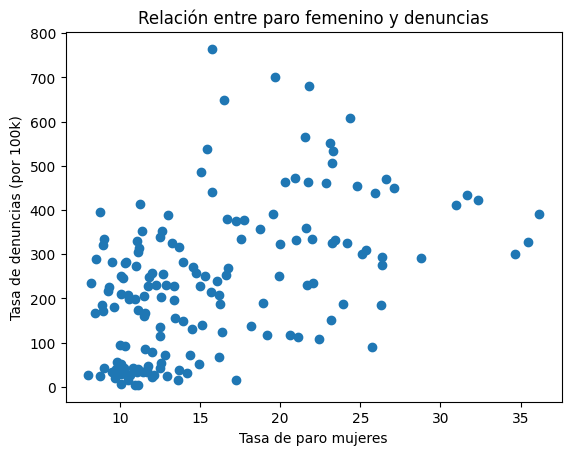

In [0]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    pdf["tasa_paro_mujeres"],
    pdf["tasa_denuncias_100k"]
)

plt.xlabel("Tasa de paro mujeres")
plt.ylabel("Tasa de denuncias (por 100k)")
plt.title("Relación entre paro femenino y denuncias")

plt.show()

Se observa una relación positiva débil a moderada con alta dispersión entre la tasa de paro femenino y la tasa de denuncias.

La elevada dispersión de los datos sugiere que el desempleo femenino, aunque relevante, no explica por sí solo la variabilidad del fenómeno.

In [0]:
display(
    df_analitico.select(
        "tasa_paro_mujeres",
        "tasa_denuncias_100k"
    )
)

tasa_paro_mujeres,tasa_denuncias_100k
11.145,173.4045752748101
11.145,4.819272807431675
10.522499999999999,15.89276879020046
19.91,250.56499950869608
21.5225,564.854088634239
20.9875,333.09146667031746
13.4275,155.91082849117245
22.03,235.37111857921434
26.332499999999996,293.55140576850863
12.5625,202.30568149972763


In [0]:
display(
    df_analitico.select(
        "renta_media_persona",
        "tasa_denuncias_100k"
    )
)

renta_media_persona,tasa_denuncias_100k
13319.0,173.4045752748101
13319.0,4.819272807431675
15539.0,15.89276879020046
11652.0,250.56499950869608
10770.0,564.854088634239
10103.0,333.09146667031746
14057.0,155.91082849117245
12123.0,235.37111857921434
10549.0,293.55140576850863
15297.0,202.30568149972763


### Relación entre renta y denuncias

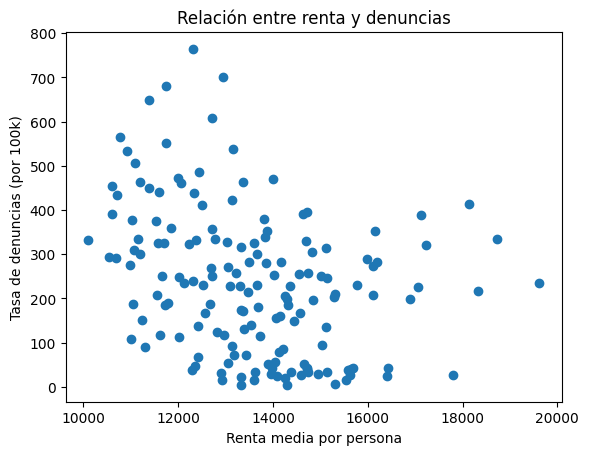

In [0]:
plt.figure()
plt.scatter(
    pdf["renta_media_persona"],
    pdf["tasa_denuncias_100k"]
)

plt.xlabel("Renta media por persona")
plt.ylabel("Tasa de denuncias (por 100k)")
plt.title("Relación entre renta y denuncias")

plt.show()

Se observa una relación negativa entre la renta media y la tasa de denuncias.

Aunque existe dispersión, se aprecia una tendencia según la cual provincias con mayor nivel de renta presentan, en términos relativos, menor incidencia de denuncias.

Este resultado sugiere la influencia de factores socioeconómicos en el fenómeno analizado.

In [0]:
display(
    df_analitico.select(
        "tasa_paro_mujeres",
        "tasa_empleo_mujeres",
        "tasa_actividad_mujeres"
    )
)

tasa_paro_mujeres,tasa_empleo_mujeres,tasa_actividad_mujeres
11.145,42.795,48.167500000000004
11.145,42.795,48.167500000000004
10.522499999999999,47.37499999999999,52.942499999999995
19.91,40.4075,50.55499999999999
21.5225,40.0275,51.015
20.9875,42.4875,53.765
13.4275,39.8375,46.027499999999996
22.03,36.655,47.06
26.332499999999996,36.3175,49.287499999999994
12.5625,49.957499999999996,57.1325


## Análisis temporal

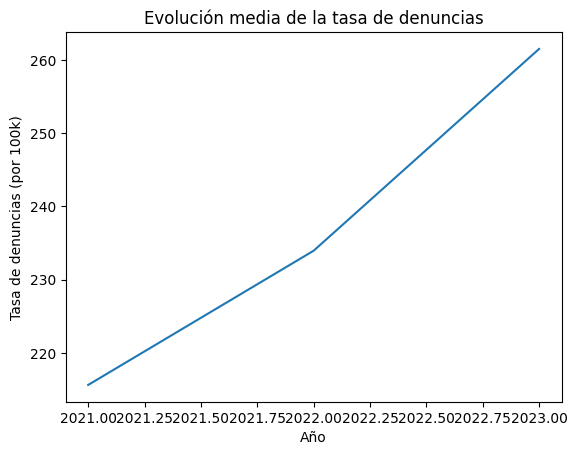

In [0]:
df_temp = pdf.groupby("anio")["tasa_denuncias_100k"].mean()

plt.figure()
df_temp.plot()

plt.title("Evolución media de la tasa de denuncias")
plt.xlabel("Año")
plt.ylabel("Tasa de denuncias (por 100k)")

plt.show()

Se observa una tendencia creciente en la tasa media de denuncias durante el periodo analizado (2021 al 2023).

No obstante, debido a la limitada longitud de la serie temporal, no es posible confirmar si esta tendencia responde a un patrón estructural o a fluctuaciones coyunturales.

El análisis exploratorio ha permitido identificar relaciones relevantes entre variables socioeconómicas y la incidencia de violencia de género.

En particular:

- La tasa de paro femenino muestra una relación positiva débil con la incidencia de denuncias.
- La renta media presenta una relación negativa con las tasas relativas de denuncias.
- Las variables normalizadas (por 100.000 habitantes) resultan más adecuadas para el análisis comparativo entre provincias.

Estos resultados validan la incorporación de variables socioeconómicas en el modelado predictivo.

El análisis exploratorio de datos confirma la existencia de relaciones relevantes entre variables socioeconómicas y la incidencia de violencia de género.

Se identifican patrones consistentes en:

- La relación entre desempleo femenino y denuncias
- La influencia del nivel de renta en la incidencia relativa del fenómeno
- La necesidad de utilizar variables normalizadas para evitar sesgos derivados del tamaño poblacional

Asimismo, se observa una tendencia temporal creciente en el periodo analizado, si bien la limitada disponibilidad de datos impide extraer conclusiones estructurales definitivas.

En conjunto, estos resultados justifican el uso de modelos predictivos en la siguiente fase del proyecto, así como la selección de variables explicativas basadas en factores socioeconómicos.

El análisis exploratorio se ha basado en técnicas descriptivas y correlacionales, por lo que los resultados no implican causalidad, sino asociaciones estadísticas que serán evaluadas en la fase de modelado.

In [0]:
df_analitico.write \
    .mode("overwrite") \
    .format("delta") \
    .save("/Volumes/workspace/default/tfm_visnu_raw/exports/df_analitico_delta")